Data Preparation using custom class

In [1]:
from ham_clf.utils.loggers import CustomLogger

logger = CustomLogger()
log = logger.get_logger()

In [2]:
from pathlib import Path

from data.images import merge_images

ROOT = Path.cwd().parent.parent
merged_directory = ROOT / "images" / "HAM10000_images_full"
merge_images(merged_directory=merged_directory, log=log)

[INFO | ham_clf.utils.loggers]
c:\Users\thank\Desktop\ham-clf\images\HAM10000_images_full already exists


In [3]:
from data.preprocessing import HAMPreprocessor

filepath = merged_directory.with_name("HAM10000_metadata.csv")
preprocessor = HAMPreprocessor(filepath=filepath, log=log)
train_df, valid_df, test_df = preprocessor.preprocess()

[INFO | ham_clf.utils.loggers]
loading_dataframe
[INFO | ham_clf.utils.loggers]
dropping_duplicates_on_lesion
[INFO | ham_clf.utils.loggers]
balance_training_dataset
[INFO | ham_clf.utils.loggers]
get_one_image_per_lesion_on_validation_dataset
[INFO | ham_clf.utils.loggers]
get_one_image_per_lesion_on_testing_dataset


In [4]:
log.info(f"{[len(df_) for df_ in (train_df, valid_df, test_df)]}")
log.info(f"max_lesion_count_on_validation: {valid_df.lesion_id.value_counts().max()}")
log.info(f"max_lesion_count_on_testing: {valid_df.lesion_id.value_counts().max()}")
log.info(train_df.dx.value_counts())

[INFO | ham_clf.utils.loggers]
[6813, 1121, 1121]
[INFO | ham_clf.utils.loggers]
max_lesion_count_on_validation: 1
[INFO | ham_clf.utils.loggers]
max_lesion_count_on_testing: 1
[INFO | ham_clf.utils.loggers]
dx
melanocytic_nevi        2500
melanoma                1113
benign_keratosis        1100
basal_cell_carcinoma     900
actinic_keratoses        600
dermatofibroma           300
vascular_lesions         300
Name: count, dtype: int64


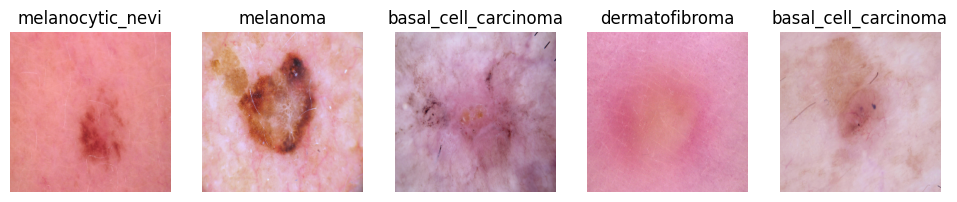

In [5]:
import matplotlib.pyplot as plt

from data.images import plot_random_image

plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plot_random_image(df=train_df, images_dir=merged_directory, size=(256, 256))